['t3.JPG']


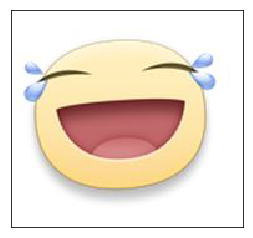

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_sample_image
import cv2
import os
print(os.listdir('../input'))

# image = load_sample_image("china.jpg") # using image in sklearn.datasets 
# image = load_sample_image("flower.jpg")

image = plt.imread('..//input//t3.JPG') 
 
# show our image
plt.figure()
plt.axis("on")
plt.xticks([])
plt.yticks([])
plt.imshow(image)


In [4]:
# reshape the image to be a list of pixels
print(image.shape)
image_temp = image.reshape((image.shape[0] * image.shape[1], 3))
print(image_temp.shape)

(175, 187, 3)
(32725, 3)


In [5]:
# cluster the pixel intensities
clt = KMeans(n_clusters = 5)
clt.fit(image_temp)

 # show scatter 
COLORS = clt.cluster_centers_
COLORS = COLORS.astype(int)
LABELS = clt.labels_
print(COLORS)
print(LABELS)

[[253 253 253]
 [188 111 107]
 [252 229 173]
 [126  63  56]
 [196 197 200]]
[0 0 0 ... 0 0 0]


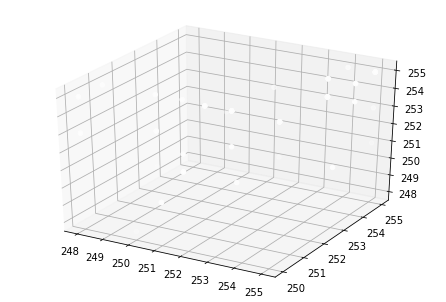

In [6]:
def rgb_to_hex(rgb):    
        return '#%02x%02x%02x' % (int(rgb[0]), int(rgb[1]), int(rgb[2]))
    
def plotClusters(COLORS,LABELS,image):
        #plotting 
        fig = plt.figure()
        ax = Axes3D(fig)        
        for label, pix in zip(LABELS, image):
            ax.scatter(pix[0], pix[1], pix[2], color = rgb_to_hex(COLORS[label]),cmap='viridis')
        plt.show()

plotClusters(COLORS,LABELS,image)

In [7]:
def centroid_histogram(clt):
    #grab the number of different clusters and create a histogram
    # based on the number of pixels assigned to each cluster
    numLabels = np.arange(0, len(np.unique(clt.labels_)) + 1)
    (hist, _) = np.histogram(clt.labels_, bins = numLabels)
    # normalize the histogram, such that it sums to one
    hist = hist.astype("float")
    hist /= hist.sum()
 
    # return the histogram
    return hist

def plot_colors(hist, centroids):
    # initialize the bar chart representing the relative frequency
    # of each of the colors
    bar = np.zeros((50, 300, 3), dtype = "uint8")
    startX = 0
 
    # loop over the percentage of each cluster and the color of
    # each cluster
    for (percent, color) in zip(hist, centroids):
    # plot the relative percentage of each cluster
        endX = startX + (percent * 300)
        cv2.rectangle(bar, (int(startX), 0), (int(endX), 50),
            color.astype("uint8").tolist(), -1)
        startX = endX

    # return the bar chart
    return bar

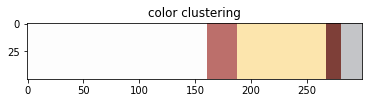

In [8]:
# build a histogram of clusters and then create a figure
# representing the number of pixels labeled to each color
hist = centroid_histogram(clt)
bar = plot_colors(hist, clt.cluster_centers_)
 
# show our color bart
plt.figure()
plt.axis("on")
# plt.yticks([])
# plt.xticks([])
plt.imshow(bar)
plt.title("color clustering")
plt.show()